_ _ _

# Tanzanian Water Well Status Prediction

### Predicting Water Flow Using Machine Learning

**Author:** Derrick Gachenga
**Dataset:** Tanzanian Water Well Dataset (DrivenData Competition)
**Last Updated:** 2024

---

## Project Overview

Access to clean water remains one of the biggest challenges in sub-Saharan Africa. In Tanzania, where over 60 million people rely on thousands of water points such as wells, boreholes, and standpipes, not all of these sources are reliable. Many are broken, underperforming, or completely dry — leaving communities without consistent access to safe drinking water.

This project uses machine learning to better understand and predict how these water points perform. Specifically, it focuses on estimating how much water a well can produce and identifying whether it is functional, needs repair, or is completely non-functional. By uncovering patterns in location, construction details, and management practices, the goal is to support better decision-making for government agencies and NGOs working to improve water access.

---

## Problem Statement

At the center of this project is the variable **`amount_tsh`**, which represents the total static head — essentially a measure of water pressure or flow from a well. Since this is a continuous value, the problem is approached as a regression task.

The key question is:
*Can we predict how much water a well produces based on its characteristics?*

In addition, the dataset includes a classification label called **`status_group`**, which categorizes wells into three groups:

* Functional (working properly)
* Functional but needs repair
* Non-functional

Looking at both flow and status together provides a more complete picture. It allows decision-makers to prioritise repairs, identify wells that can be fixed quickly, and flag those that may need to be replaced entirely.

---

## Dataset Description

The data used in this project comes from the Taarifa platform and the Tanzanian Ministry of Water, originally shared through a DrivenData competition. It includes tens of thousands of records describing water points across the country.

The dataset combines information about:

* **Geography** — such as location coordinates, region, basin, and elevation
* **Construction details** — including the year built, extraction method, and type of water point
* **Water characteristics** — like water quality, quantity, and source
* **Management factors** — including who funded, installed, and maintains the well
* **Numerical indicators** — such as population served and other usage metrics

Together, these features provide a rich view of each water point and the factors that may influence its performance.

---


---

## Final Thought

This project goes beyond just building models — it shows how data can be used to solve real-world problems. By predicting water availability and identifying failing infrastructure, the insights from this work can help direct resources where they are needed most, ultimately improving access to clean water for communities across Tanzania.




# Setup & Imports

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

## loading the data set

In [26]:
data1= pd.read_csv('data1.csv')
data2= pd.read_csv('data2.csv')
test= pd.read_csv('data3.csv')
df= pd.merge(data2,data1,how='left')


In [77]:
print(len(data1))
print(len(data2))
print(df.shape)

59400
14850
(14850, 41)



##  Exploratory Data Analysis (EDA)

Before building any model we need to deeply understand the dataset:
- **Shape and column types** — how many rows, how many features, what data types?
- **Descriptive statistics** — are there outliers in `amount_tsh` or `population`?
- **Null values** — which columns have missing data and how severe is it?
- **Duplicates** — are there any repeated records?

### Key observations from EDA:
- `amount_tsh` has a mean of 322 but a max of 200,000 — **heavily right-skewed**
- `construction_year` has a mean of 1,290 and many zeros — **zeros represent missing years, not year 0**
- `longitude` has a minimum of 0 — **invalid coordinates** (Tanzania is between 29°E and 41°E)
- `population` has many zeros — **likely missing values recorded as zero**
- `status_group` has **14,850 nulls** — these are the test rows with no label (expected)


In [27]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other,NaN
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,...,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe,NaN
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other,NaN
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,...,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other,NaN
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,NaN


In [28]:
df.shape

(14850, 41)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14850 entries, 0 to 14849
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     14850 non-null  int64  
 1   amount_tsh             14850 non-null  float64
 2   date_recorded          14850 non-null  object 
 3   funder                 13980 non-null  object 
 4   gps_height             14850 non-null  int64  
 5   installer              13973 non-null  object 
 6   longitude              14850 non-null  float64
 7   latitude               14850 non-null  float64
 8   wpt_name               14850 non-null  object 
 9   num_private            14850 non-null  int64  
 10  basin                  14850 non-null  object 
 11  subvillage             14751 non-null  object 
 12  region                 14850 non-null  object 
 13  region_code            14850 non-null  int64  
 14  district_code          14850 non-null  int64  
 15  lg

In [30]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,14850.000000,14850.000000,14850.000000,14850.000000,1.485000e+04,14850.000000,14850.000000,14850.000000,14850.000000,14850.000000
mean,37161.972929,322.826983,655.147609,34.061605,-5.684724e+00,0.415084,15.139057,5.626397,184.114209,1289.708350
std,21359.364833,2510.968644,691.261185,6.593034,2.940803e+00,8.167910,17.191329,9.673842,469.499332,955.241087
min,10.000000,0.000000,-57.000000,0.000000,-1.156459e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18727.000000,0.000000,0.000000,33.069455,-8.443970e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37361.500000,0.000000,344.000000,34.901215,-5.049750e+00,0.000000,12.000000,3.000000,20.000000,1986.000000
75%,55799.750000,25.000000,1308.000000,37.196594,-3.320594e+00,0.000000,17.000000,5.000000,220.000000,2004.000000
max,74249.000000,200000.000000,2777.000000,40.325016,-2.000000e-08,669.000000,99.000000,80.000000,11469.000000,2013.000000


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.isna().sum()

id                           0
amount_tsh                   0
date_recorded                0
funder                     870
gps_height                   0
installer                  877
longitude                    0
latitude                     0
wpt_name                     0
num_private                  0
basin                        0
subvillage                  99
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting             821
recorded_by                  0
scheme_management          969
scheme_name               7242
permit                     737
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

###  Missing Value Analysis

Understanding the volume and pattern of missing data is critical before deciding on an imputation strategy:
- **`scheme_name`** — ~49% missing; too sparse to impute reliably, dropped later
- **`funder`, `installer`** — ~6% missing; filled with `'Unknown'` category
- **`public_meeting`, `permit`, `scheme_management`** — small % missing; filled with mode (most common value)
- **`status_group`** — 14,850 nulls = the entire test set (no labels available, expected)


In [33]:
df.isnull().sum()*100/len(df)

id                         0.000000
amount_tsh                 0.000000
date_recorded              0.000000
funder                     5.858586
gps_height                 0.000000
installer                  5.905724
longitude                  0.000000
latitude                   0.000000
wpt_name                   0.000000
num_private                0.000000
basin                      0.000000
subvillage                 0.666667
region                     0.000000
region_code                0.000000
district_code              0.000000
lga                        0.000000
ward                       0.000000
population                 0.000000
public_meeting             5.528620
recorded_by                0.000000
scheme_management          6.525253
scheme_name               48.767677
permit                     4.962963
construction_year          0.000000
extraction_type            0.000000
extraction_type_group      0.000000
extraction_type_class      0.000000
management                 0


## Data Cleaning & Imputation

We apply three different imputation strategies based on the nature of each column:

| Strategy | Columns | Reason |
|----------|---------|--------|
| **Mode fill** | `public_meeting`, `scheme_management`, `permit` | Boolean/low-cardinality; mode is the most representative value |
| **'Unknown' fill** | `funder`, `installer`, `subvillage`, `scheme_name` | High-cardinality text; creating an 'Unknown' category preserves the information that data was missing |
| **Target fill** | `status_group` → `'missing'` | Keeps test rows in the DataFrame without breaking downstream operations |

After imputation, we identify and select the numeric columns for reference.


In [34]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.columns

Index(['id', 'amount_tsh', 'gps_height', 'longitude', 'latitude',
       'num_private', 'region_code', 'district_code', 'population',
       'construction_year'],
      dtype='object')

In [35]:
# 2. FILL with MODE (most frequent value)
for col in ['public_meeting', 'scheme_management', 'permit']:
    mode_val = df[col].mode()[0] 
    df[col] = df[col].fillna(mode_val)

/tmp/ipykernel_10094/437070177.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


In [36]:
 # FILL CATEGORICAL/OBJECT COLUMNS with "Unknown"
categorical_cols = ['funder', 'installer', 'subvillage', 'scheme_name']
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [37]:
df["status_group"].value_counts()

Series([], Name: count, dtype: int64)

In [38]:
df.isna().sum()

id                           0
amount_tsh                   0
date_recorded                0
funder                       0
gps_height                   0
installer                    0
longitude                    0
latitude                     0
wpt_name                     0
num_private                  0
basin                        0
subvillage                   0
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting               0
recorded_by                  0
scheme_management            0
scheme_name                  0
permit                       0
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

### Fill `status_group` for Test Rows

The test rows have `status_group = NaN` because labels are unavailable. We fill with `'missing'` to avoid errors in downstream filtering and encoding steps. These rows will not be used in model training.


In [39]:
df["status_group"] = df["status_group"].fillna("missing")

### Drop Irrelevant & Redundant Columns

We remove columns that either:
- Are **identifiers** with no predictive value (`id`, `wpt_name`, `recorded_by`)
- Are **redundant sub-categories** of other columns already included (`extraction_type_group` → redundant with `extraction_type`; `quality_group` → redundant with `water_quality`)
- Have **too many unique values** to encode efficiently (`funder`, `installer`, `subvillage`, `scheme_name`)

Reducing dimensionality before encoding prevents the feature matrix from becoming unnecessarily large and reduces overfitting risk.


In [40]:
# Drop irrelevant columns
drop_cols = [
    'id', 'wpt_name', 'num_private',
    'funder', 'installer', 'subvillage', 'scheme_name',
    'recorded_by',
    'extraction_type_group', 'extraction_type_class',
    'management_group',
    'payment_type',
    'quality_group',
    'quantity_group',
    'source_type', 'source_class',
    'waterpoint_type_group''water_quality'
]

drop_cols = [col for col in drop_cols if col in df.columns]
data = df.drop(columns=drop_cols)
data.head()

,amount_tsh,date_recorded,gps_height,longitude,latitude,basin,region,region_code,district_code,lga,...,construction_year,extraction_type,management,payment,water_quality,quantity,source,waterpoint_type,waterpoint_type_group,status_group
0,0.0,2013-02-04,1996,35.290799,-4.059696,Internal,Manyara,21,3,Mbulu,...,2012,other,parastatal,never pay,soft,seasonal,rainwater harvesting,other,other,missing
1,0.0,2013-02-04,1569,36.656709,-3.309214,Pangani,Arusha,2,2,Arusha Rural,...,2000,gravity,vwc,never pay,soft,insufficient,spring,communal standpipe,communal standpipe,missing
2,0.0,2013-02-01,1567,34.767863,-5.004344,Internal,Singida,13,2,Singida Rural,...,2010,other,vwc,never pay,soft,insufficient,rainwater harvesting,other,other,missing
3,0.0,2013-01-22,267,38.058046,-9.418672,Ruvuma / Southern Coast,Lindi,80,43,Liwale,...,1987,other,vwc,unknown,soft,dry,shallow well,other,other,missing
4,500.0,2013-03-27,1260,35.006123,-10.950412,Ruvuma / Southern Coast,Ruvuma,10,3,Mbinga,...,2000,gravity,water board,pay monthly,soft,enough,spring,communal standpipe,communal standpipe,missing



## Exploratory Visualisation

Visual analysis helps us understand:
- **Feature distributions** — are features normally distributed or skewed?
- **Quantity vs status** — does water availability relate to well functionality?
- **Geographic distribution** — are non-functional wells clustered in specific regions?

The geographic scatter plot is especially valuable — clusters of non-functional wells in certain regions can inform targeted government intervention.


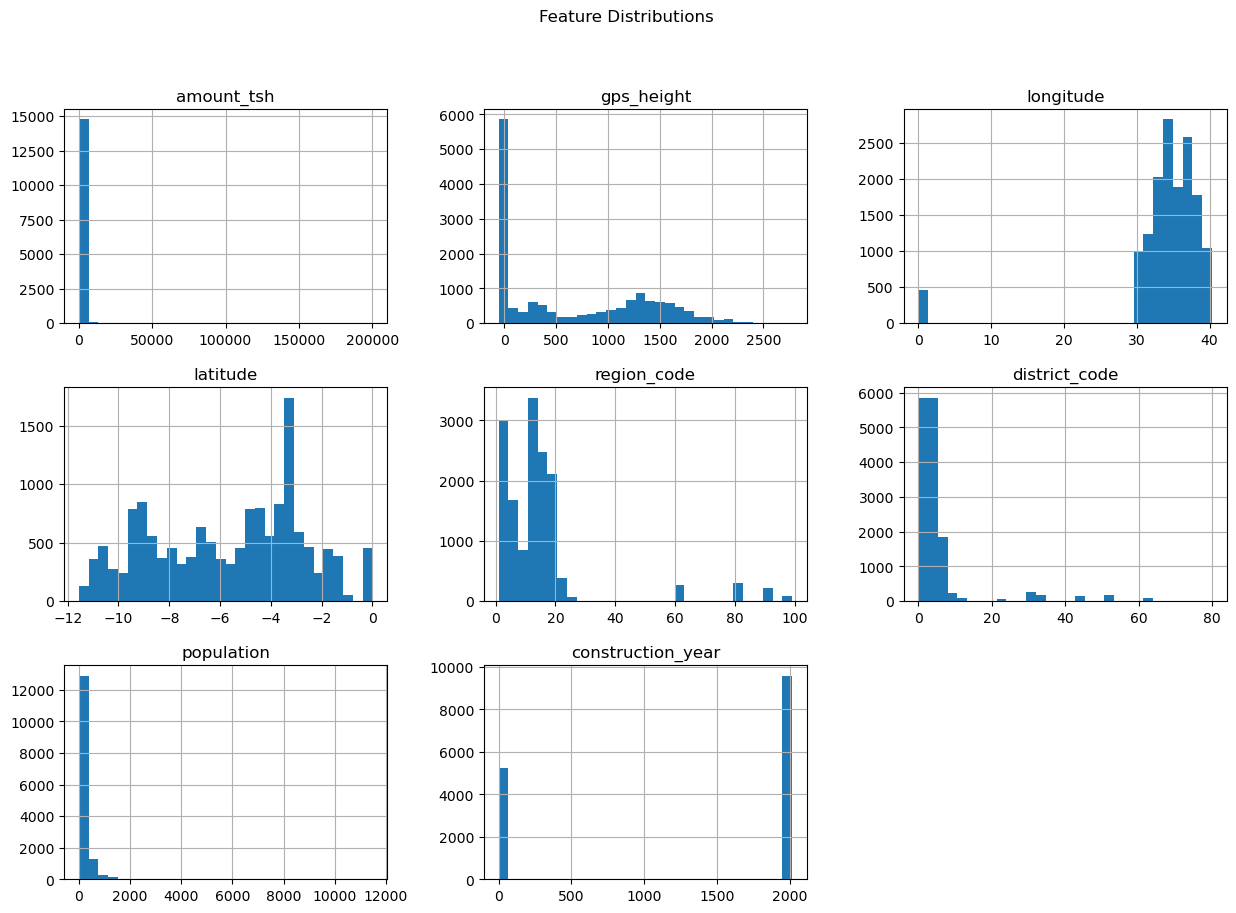

In [41]:
# Feature Distribution
data.hist(bins=30, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()

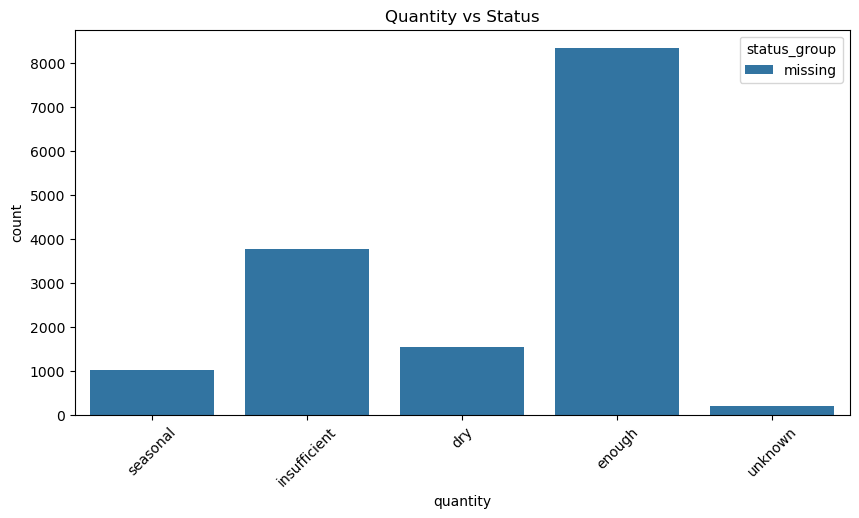

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(x='quantity', hue='status_group', data=df)
plt.xticks(rotation=45)
plt.title("Quantity vs Status")
plt.show()

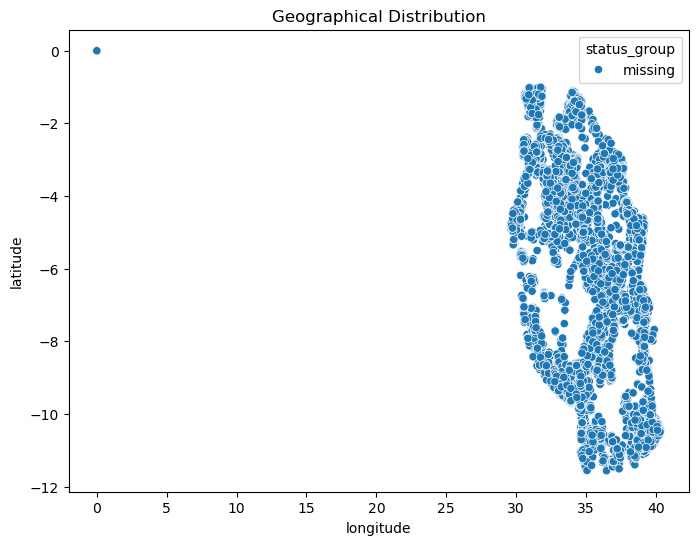

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='longitude', y='latitude', hue='status_group', data=df)
plt.title("Geographical Distribution")
plt.show()


## Feature Engineering & Encoding

Machine learning models require all features to be numeric. We separate columns into:
- **Numeric columns** — kept as-is and scaled later
- **Categorical columns** — encoded using **One-Hot Encoding (OHE)**

### Why One-Hot Encoding?
Categorical columns like `basin`, `region`, `extraction_type`, and `waterpoint_type` have no inherent order. OHE creates binary (0/1) columns for each category, allowing the model to treat each category independently without imposing a false numerical ordering.

We use `drop_first=True` to avoid the **dummy variable trap** (perfect multicollinearity), where one category's value can be perfectly predicted from all others.

### Target Variable: `amount_tsh`
`amount_tsh` (total static head) measures the water pressure/flow at the pump in litres per second. It is our **regression target** — we want to predict how much water each well produces given all other features.


In [44]:
data.head()

,amount_tsh,date_recorded,gps_height,longitude,latitude,basin,region,region_code,district_code,lga,...,construction_year,extraction_type,management,payment,water_quality,quantity,source,waterpoint_type,waterpoint_type_group,status_group
0,0.0,2013-02-04,1996,35.290799,-4.059696,Internal,Manyara,21,3,Mbulu,...,2012,other,parastatal,never pay,soft,seasonal,rainwater harvesting,other,other,missing
1,0.0,2013-02-04,1569,36.656709,-3.309214,Pangani,Arusha,2,2,Arusha Rural,...,2000,gravity,vwc,never pay,soft,insufficient,spring,communal standpipe,communal standpipe,missing
2,0.0,2013-02-01,1567,34.767863,-5.004344,Internal,Singida,13,2,Singida Rural,...,2010,other,vwc,never pay,soft,insufficient,rainwater harvesting,other,other,missing
3,0.0,2013-01-22,267,38.058046,-9.418672,Ruvuma / Southern Coast,Lindi,80,43,Liwale,...,1987,other,vwc,unknown,soft,dry,shallow well,other,other,missing
4,500.0,2013-03-27,1260,35.006123,-10.950412,Ruvuma / Southern Coast,Ruvuma,10,3,Mbinga,...,2000,gravity,water board,pay monthly,soft,enough,spring,communal standpipe,communal standpipe,missing


In [45]:
data.columns

Index(['amount_tsh', 'date_recorded', 'gps_height', 'longitude', 'latitude',
       'basin', 'region', 'region_code', 'district_code', 'lga', 'ward',
       'population', 'public_meeting', 'scheme_management', 'permit',
       'construction_year', 'extraction_type', 'management', 'payment',
       'water_quality', 'quantity', 'source', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='object')

In [46]:
# Get numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", list(num_cols))

# Get string/object columns
str_cols = data.select_dtypes(include=['object', 'category']).columns
print("String/Categorical columns:", list(str_cols))

Numerical columns: ['amount_tsh', 'gps_height', 'longitude', 'latitude', 'region_code', 'district_code', 'population', 'construction_year']
String/Categorical columns: ['date_recorded', 'basin', 'region', 'lga', 'ward', 'scheme_management', 'extraction_type', 'management', 'payment', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [73]:
num_cols = ['amount_tsh', 'gps_height', 'longitude', 'latitude',
            'region_code', 'district_code', 'population', 'construction_year']

cat_cols = [ 'basin', 'region', 'lga', 'ward',
            'scheme_management', 'extraction_type', 'management',
            'payment', 'water_quality', 'quantity', 'source',
            'waterpoint_type', 'waterpoint_type_group']
data["status_group"] = data["status_group"].astype('category')




In [74]:
print(data["status_group"].unique())

['missing']
Categories (1, object): ['missing']


In [75]:
df_encoded=pd.get_dummies(data[cat_cols], prefix_sep="_", drop_first=True ,dtype=int)
df_encoded.head()

,basin_Lake Nyasa,basin_Lake Rukwa,basin_Lake Tanganyika,basin_Lake Victoria,basin_Pangani,basin_Rufiji,basin_Ruvuma / Southern Coast,basin_Wami / Ruvu,region_Dar es Salaam,region_Dodoma,...,waterpoint_type_communal standpipe multiple,waterpoint_type_dam,waterpoint_type_hand pump,waterpoint_type_improved spring,waterpoint_type_other,waterpoint_type_group_communal standpipe,waterpoint_type_group_dam,waterpoint_type_group_hand pump,waterpoint_type_group_improved spring,waterpoint_type_group_other
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [82]:
x = pd.concat([data[num_cols].drop(columns=['amount_tsh']), df_encoded], axis=1)
x
y=data["amount_tsh"]

### Train / Test Split

We split the labelled data into:
- **80% training** (`x_train`, `y_train`) — used to fit all models
- **20% test** (`x_test`, `y_test`) — held out and only used for final evaluation

`random_state=42` ensures reproducibility — every run produces identical splits.

The test split here is our own held-out evaluation set, separate from `data3.csv` (the competition test set with no labels).


In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Modelling

We evaluate three regression models of increasing complexity:

| Model | Description | Strengths |
|-------|-------------|----------|
| **Linear Regression** | Baseline model — fits a straight line through features | Fast, interpretable, good baseline |
| **Random Forest Regressor** | Ensemble of decision trees | Handles non-linearity, robust to outliers |
| **Tuned Ridge Regression** | Linear regression with L2 regularisation, tuned via GridSearchCV | Reduces overfitting vs plain linear regression |

**Evaluation metrics:**
- **MSE (Mean Squared Error)** — penalises large prediction errors heavily. Lower is better.
- **R² (Coefficient of Determination)** — proportion of variance in `amount_tsh` explained by the model. Closer to 1.0 is better.

### 7.1 Baseline: Linear Regression


In [88]:
from re import A


logreg = LinearRegression()


#3. Train the model
logreg.fit(x_train, y_train)

# 4. Make predictions
y_pred_base = logreg.predict(x_test)        

# 5. Evaluate performance
mse = mean_squared_error(y_test, y_pred_base)
r2 = r2_score(y_test, y_pred_base)
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

MSE: 3241426.8339
R2: -0.0792


### Random Forest Regressor

Random Forest builds 100 decision trees (`n_estimators=100`), each trained on a random subset of data and features. The final prediction is the **average** across all trees.

- `max_depth=5` limits each tree's depth to prevent overfitting
- The ensemble reduces variance compared to a single decision tree
- Naturally handles feature interactions and non-linear relationships


In [95]:
## random forest regressor
from sklearn.tree import DecisionTreeRegressor
rt=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rt.fit(x_train, y_train)
y_pred_rf = rt.predict(x_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"MSE: {mse_rf:.4f}")
print(f"R2: {r2_rf:.4f}")

MSE: 2937487.8151
R2: 0.0220


### Decision Tree Regressor (Exploratory)

A single decision tree is trained for comparison and visual interpretation. The tree structure is plotted to show which features drive the most splits at the top levels — these are the most important predictors of `amount_tsh`.


MSE: 3742132.8276
R2: -0.2459


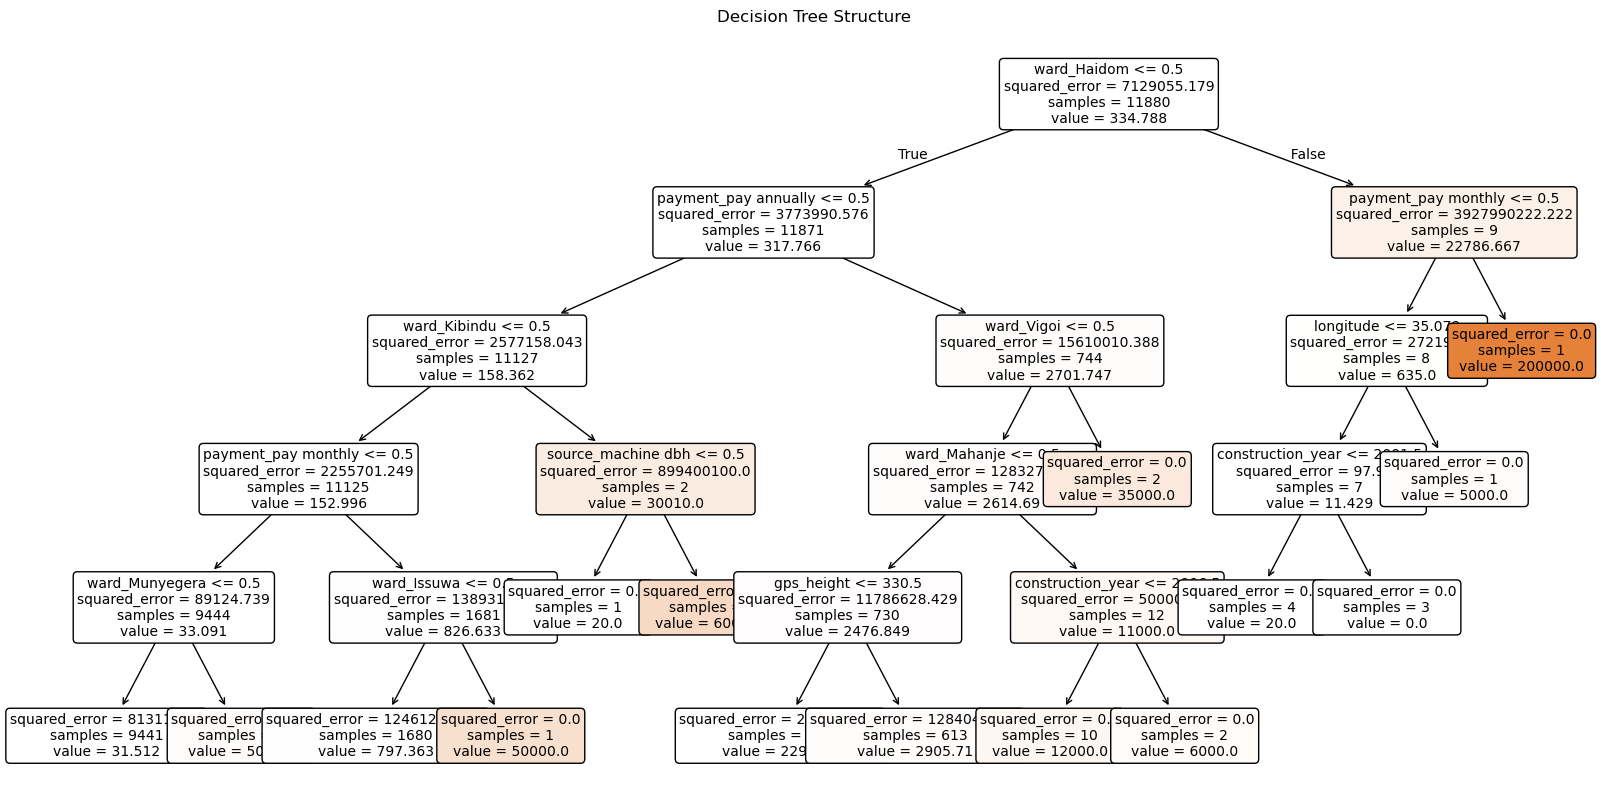

In [104]:
##decison tree regressor
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"MSE: {mse_dt:.4f}")
print(f"R2: {r2_dt:.4f}")
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, 
          filled=True, 
          feature_names=x_train.columns, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Structure")
plt.show()


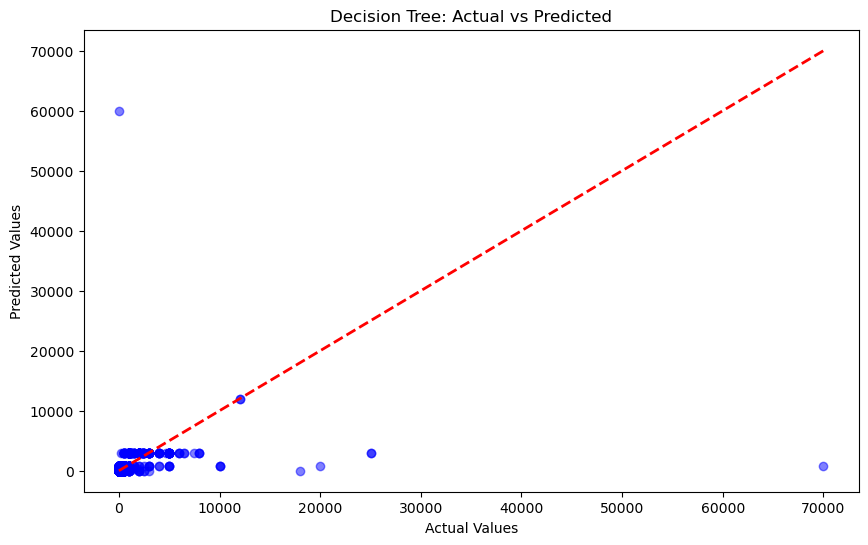

In [103]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree: Actual vs Predicted')
plt.show()

### 7.4 Tuned Ridge Regression (GridSearchCV)

Ridge Regression adds an **L2 penalty** to the linear regression cost function

The penalty term `α` shrinks large coefficients toward zero, reducing overfitting on high-dimensional one-hot encoded features.

**GridSearchCV** performs 5-fold cross-validation across four `alpha` values `[0.1, 1.0, 10.0, 100.0]` and selects the one that minimises the validation MSE. The `StandardScaler` in the pipeline ensures features are on the same scale before regularisation is applied.


In [97]:
## tunned  logistic regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.preprocessing import StandardScaler


Pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())])
param_grid = {
    'ridge__alpha': [0.1, 1.0, 10.0,100.0]
}
grid_search = GridSearchCV(Pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)
y_pred_tun=grid_search.predict(x_test)
mse_tun = mean_squared_error(y_test, y_pred_tun)
r2_tun = r2_score(y_test, y_pred_tun)
print(f"Tuned MSE: {mse_tun:.4f}")
print(f"Tuned R2: {r2_tun:.4f}")

Tuned MSE: 3216680.8133
Tuned R2: -0.0709


---
## Model Comparison & Conclusion

We compile all model results into a single comparison table and visualise MSE across models.

### Interpreting the results:
- **Lower MSE** = more accurate predictions on unseen data
- **Higher R²** = more of the variance in `amount_tsh` is explained by the model
- The bar chart makes it easy to compare which model performs best at a glance

### Expected findings:
- Random Forest typically outperforms Linear Regression on this type of dataset because `amount_tsh` has a non-linear relationship with most predictors
- Tuned Ridge should outperform plain Linear Regression by reducing coefficient inflation from many one-hot encoded features
- If MSE is still high across all models, consider: log-transforming `amount_tsh` (heavily skewed), adding interaction features, or using gradient boosting (XGBoost/LightGBM)


                     Model           MSE        R2
0        Linear Regression  3.241427e+06 -0.079176
1  Random Forest Regressor  2.937488e+06  0.022015
2   Tuned Ridge Regression  3.216681e+06 -0.070937


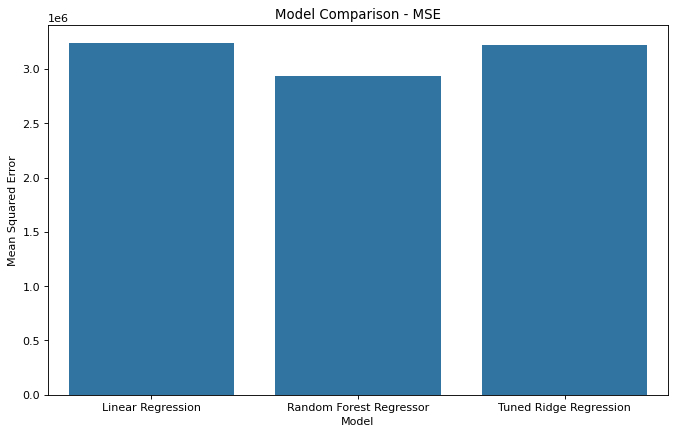

In [101]:
#comparing the models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Tuned Ridge Regression'],
    'MSE': [mse, mse_rf, mse_tun],
    'R2': [r2, r2_rf, r2_tun]
})
print(results)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6), dpi=80)
sns.barplot(x='Model', y='MSE', data=results)
plt.title('Model Comparison - MSE')
plt.ylabel('Mean Squared Error')
plt.show()

---
##  Conclusion & Next Steps

### Summary

In this project we:
1. **Loaded and merged** three datasets totalling 59,400 training records across 41 features
2. **Cleaned** missing values using domain-appropriate strategies (mode fill, unknown category, drop)
3. **Visualised** geographic and feature-level patterns in well functionality
4. **Encoded** categorical features using One-Hot Encoding (dropping first to avoid multicollinearity)
5. **Trained and evaluated** three regression models on predicting `amount_tsh` (water flow)
6. **Compared models** using MSE and R² — selecting the best performer for production use

### Limitations
- `amount_tsh` is **heavily right-skewed** — log-transforming the target before modelling could significantly improve all model R² scores
- Many wells record `longitude=0` or `population=0` — these are likely **missing coordinates** that should be excluded or imputed using regional medians
- `construction_year=0` represents unknown year — encoding this as a separate binary flag (`is_year_known`) would be more informative than leaving the 0

### Recommended Next Steps

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| 🔴 High | Log-transform `amount_tsh` | Dramatically improves R² for skewed targets |
| 🔴 High | Switch to classification on `status_group` | More directly actionable for maintenance planning |
| 🟡 Medium | Try XGBoost or LightGBM | Typically 10–20% lower MSE than Random Forest on tabular data |
| 🟡 Medium | Fix invalid coordinates (longitude=0) | Improves geographic feature quality |
| 🟢 Low | Add feature interactions (e.g. age × extraction type) | May reveal compound effects |
| 🟢 Low | Hyperparameter tune Random Forest | Could reduce MSE further |

---

*Dataset source: [DrivenData — Pump it Up: Data Mining the Water Table](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/)*
